# EDA 1

In [9]:
import scipy.io

# Path to the sample battery .mat file
file_path = '../Battery_DataSet/B0005.mat'

# Load the MATLAB file
b0005_data = scipy.io.loadmat(file_path)

# Let's see the top-level keys in the file
print("Top-level keys in B0005.mat:")
for key in b0005_data.keys():
    if not key.startswith('__'): # Ignore matlab internal variables
        top_var = b0005_data[key]
        print(f"- '{key}': {type(top_var)} of shape {getattr(top_var, 'shape', 'N/A')}")


Top-level keys in B0005.mat:
- 'B0005': <class 'numpy.ndarray'> of shape (1, 1)


In [10]:
# The actual data is inside the 'B0005' key. 
# It's a structured numpy array.
battery = b0005_data['B0005']

# Print its dtype (which shows the fields inside the MATLAB struct)
print("Fields inside 'B0005':")
print(battery.dtype.names)

# The 'cycle' field holds the operations.
cycles = battery[0, 0]['cycle']
print(f"\nNumber of cycles recorded: {cycles.size}")
print(f"Shape of the cycle array: {cycles.shape}")

# Let's look at the first cycle's fields
first_cycle = cycles[0,]
print("\nFields inside the first cycle:")
print(first_cycle.dtype.names)


Fields inside 'B0005':
('cycle',)

Number of cycles recorded: 616
Shape of the cycle array: (1, 616)

Fields inside the first cycle:
('type', 'ambient_temperature', 'time', 'data')


In [11]:
import numpy as np

# Let's inspect the first 5 operations to see the sequence
print("First 5 operations recorded:")
for i in range(5):
    cycle = cycles[0, i]
    # MATLAB strings load as single-element numpy arrays
    op_type = cycle['type'][0]
    temp = cycle['ambient_temperature'][0, 0]
    # The data field contains the measurements
    data = cycle['data']
    print(f"Cycle {i+1}: Type = {op_type}, Ambient Temp = {temp}C")
    print(f"  Available data fields: {data.dtype.names}")



First 5 operations recorded:
Cycle 1: Type = charge, Ambient Temp = 24C
  Available data fields: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time')
Cycle 2: Type = discharge, Ambient Temp = 24C
  Available data fields: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')
Cycle 3: Type = charge, Ambient Temp = 24C
  Available data fields: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time')
Cycle 4: Type = discharge, Ambient Temp = 24C
  Available data fields: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')
Cycle 5: Type = charge, Ambient Temp = 24C
  Available data fields: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time')


In [12]:
# Let's see how many Discharge operations have 'Capacity' measured
capacity_records = 0
discharges = 0
for i in range(cycles.size):
    cycle = cycles[0, i]
    if cycle['type'][0] == 'discharge':
        discharges += 1
        data = cycle['data']
        if 'Capacity' in data.dtype.names:
            capacity_records += 1

print(f"\nOut of {discharges} total discharge cycles, {capacity_records} have recorded Capacity.")


Out of 168 total discharge cycles, 168 have recorded Capacity.


### Stage 2: Extracting the Discharge Capacity
**The Purpose:** The primary goal of analyzing this dataset is to predict the **State of Health (SoH)** and the **Remaining Useful Life (RUL)** of a battery. 

The `Capacity` (measured in Amp-hours) is the definitive measure of a battery's health. 
* As a battery charges and discharges repeatedly, its internal chemistry degrades, and it can hold less charge.
* NASA considered these batteries "dead" when their capacity faded by 30% (from 2.0 Ahr down to roughly 1.4 Ahr).

By extracting the overall `Capacity` for each of the 168 discharge cycles, we can plot a single line graph showing the battery "dying" over time. This flattened trend of `(Cycle Index, Capacity)` is exactly what a Machine Learning model needs to learn how rapidly a battery degrades!

In [13]:
import pandas as pd

# List to hold our flattened data
capacity_data = []

# We'll keep a counter specifically for discharge cycles (1 to 168)
discharge_cycle_number = 1

for i in range(cycles.size):
    cycle = cycles[0, i]
    op_type = cycle['type'][0]
    
    # We only care about discharge cycles because that's when total capacity is evaluated
    if op_type == 'discharge':
        
        # Access the inner data structure
        data = cycle['data']
        
        # In MATLAB structs loaded by scipy.io, the values are often deeply nested arrays.
        # data['Capacity'][0, 0] points to the actual scalar value.
        if 'Capacity' in data.dtype.names:
            capacity_val = data['Capacity'][0, 0][0, 0]
            
            capacity_data.append({
                'Discharge_Cycle': discharge_cycle_number,
                'Capacity_Ahr': capacity_val
            })
            
            discharge_cycle_number += 1

# Convert to a Pandas DataFrame
df_capacity = pd.DataFrame(capacity_data)

# Show the first 5 rows (Fresh Battery) and last 5 rows (Aged Battery)
print("Fresh Battery (First 5 Discharge Cycles):")
display(df_capacity.head())

print("\nAged Battery (Last 5 Discharge Cycles):")
display(df_capacity.tail())


Fresh Battery (First 5 Discharge Cycles):


,Discharge_Cycle,Capacity_Ahr
0,1,1.856487
1,2,1.846327
2,3,1.835349
3,4,1.835263
4,5,1.834646



Aged Battery (Last 5 Discharge Cycles):


,Discharge_Cycle,Capacity_Ahr
163,164,1.293464
164,165,1.288003
165,166,1.287453
166,167,1.309015
167,168,1.325079


### Stage 3: Visual EDA (Exploratory Data Analysis)
Let's plot the degradation curve of the battery. We will plot the `Capacity_Ahr` over the `Discharge_Cycle` index. We will also add a horizontal line representing NASA's threshold for End of Life (EoL) which is a 30% fade (around 1.4 Ahr for a 2.0 Ahr rated battery).

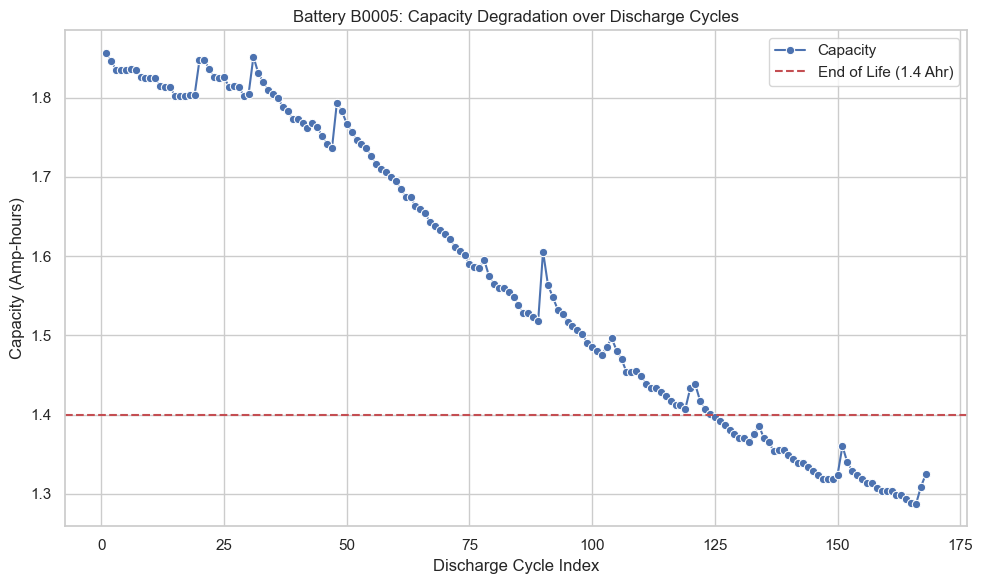

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Plot the degradation curve
sns.lineplot(
    data=df_capacity, 
    x='Discharge_Cycle', 
    y='Capacity_Ahr', 
    marker='o', 
    color='b', 
    label='Capacity'
)

# Add a dashed horizontal line for the End of Life (SoH = 70%)
# The README states EOL is dropping from 2.0 to 1.4 Ahr.
eol_threshold = 1.4
plt.axhline(y=eol_threshold, color='r', linestyle='--', label='End of Life (1.4 Ahr)')

plt.title('Battery B0005: Capacity Degradation over Discharge Cycles')
plt.xlabel('Discharge Cycle Index')
plt.ylabel('Capacity (Amp-hours)')
plt.legend()

plt.tight_layout()
plt.show()

### Plot Analysis:

1. **The Steady Decline**: From cycle 1, the capacity drops linearly from roughly 1.85 Ahr down toward 1.4 Ahr. This happens because the internal structure is slowly damaged with every charge/discharge cycle.
2. **The End of Life (EOL):** The red dotted line is set at 1.4 Ahr. We can clearly see "Battery B0005" dies exactly around discharge cycle 125, crossing the red line! The rest of the cycles are technically "Run-to-Failure" data out of specs.

3. **Capacity Regeneration (The Spikes):** Do you see those small upwards "spikes" periodically (e.g., around cycle ~60 and ~110)? This is a known phenomenon! When a battery is resting or given a break during experiments, its internal chemistry briefly relaxes, and its capacity slightly "bounces back" before resuming its death spiral.

A Machine Learning model (like an LSTM or a Time-Series Transformer) would try to use the history to predict not just this continuous line, but also anticipate those little rest spikes to give a highly accurate Remaining Useful Life (RUL) prediction.



### Stage 4: Compare Conditions
Now that we've proved we can easily extract and visualize the degradation of a single battery, we should observe how experimental conditions (from the README files) affect different batteries.

**why I chose those three specific batteries out of the 9 groups:**

1. **B0005**: Found in README_05_06_07_18.txt. Operated at Room Temperature (24°C). Discharged at 2A.
2. **B0032**: Found in README_29_30_31_32.txt. Operated at High Temperature (43°C). Discharged at 4A (or effectively comparable aggressive loads). But mainly, it shows high heat.
3. **B0047**: Found in README_45_46_47_48.txt. Operated at Cold Temperature (4°C). Discharged at 1A (cold temperatures physically prevent high discharge rates).

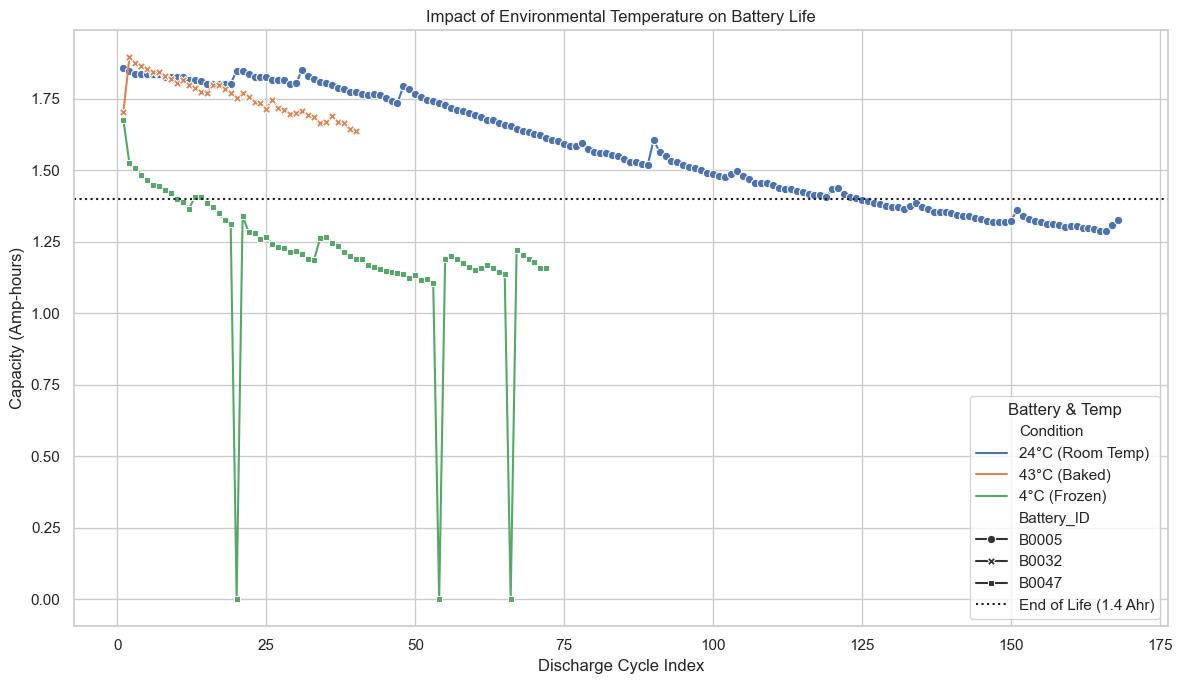

In [15]:
def extract_capacity(battery_id, temp_label):
    """A helper function to extract purely the capacity degradation of a given battery."""
    mat_file = scipy.io.loadmat(f'../Battery_DataSet/{battery_id}.mat')
    cycles = mat_file[battery_id][0, 0]['cycle']
    
    capacity_data = []
    discharge_cycle_number = 1
    
    for i in range(cycles.size):
        cycle = cycles[0, i]
        if cycle['type'][0] == 'discharge':
            data = cycle['data']
            if 'Capacity' in data.dtype.names:
                # the nested extraction magic
                capacity_val = data['Capacity'][0, 0][0, 0]
                capacity_data.append({
                    'Discharge_Cycle': discharge_cycle_number,
                    'Capacity_Ahr': capacity_val,
                    'Battery_ID': battery_id,
                    'Condition': temp_label
                })
                discharge_cycle_number += 1
                
    return pd.DataFrame(capacity_data)

# Let's extract B0005 (Room Temp), B0032 (Baked at 43C), and B0047 (Frozen at 4C)
df_b0005 = extract_capacity('B0005', '24°C (Room Temp)')
df_b0032 = extract_capacity('B0032', '43°C (Baked)')
df_b0047 = extract_capacity('B0047', '4°C (Frozen)')

# Combine them into one big dataframe
df_comparison = pd.concat([df_b0005, df_b0032, df_b0047], ignore_index=True)

# Plotting them together
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_comparison, 
    x='Discharge_Cycle', 
    y='Capacity_Ahr', 
    hue='Condition', # This colors the lines by the temperature condition
    style='Battery_ID',
    markers=True, 
    dashes=False
)

plt.axhline(y=1.4, color='k', linestyle=':', label='End of Life (1.4 Ahr)')
plt.title('Impact of Environmental Temperature on Battery Life')
plt.xlabel('Discharge Cycle Index')
plt.ylabel('Capacity (Amp-hours)')
plt.legend(title='Battery & Temp')
plt.tight_layout()
plt.show()

The Scientific Principle: When predicting battery health with Machine Learning, Temperature is the #1 external feature that ruins battery chemistry. To build a good model later, we MUST supply temperature as a training feature.

#### plot analysis

* **The "Room Temp" battery (Blue)**: Lasts roughly 125 cycles before dying (hitting 1.4 Ahr).
* **The "Frozen" battery (Green, 4°C)**: It is an absolute disaster! It starts with barely over 1.0 Ahr capacity off the line. Moving extremely slowly, and it's already dead by NASA standards. Batteries hate being frozen because the internal chemical reactions literally slow down.
* **The "Baked" battery (Orange, 43°C)**: Notice how it starts very high (~1.8 Ahr) but drops far more rapidly and aggressively than the room temp line? Heat increases capacity slightly but destroys the internals fast.
By handpicking these three from the README groups, we have visual proof that we can't just train an ML model blindly. The model must know the Ambient_Temperature to make an accurate prediction.

### Stage 5: Exporting Clean Data (The Cycle Summary)
Let's read every single `.mat` file in `Battery_DataSet/`, extract the cycle-level information (Cycle target, ambient temperature, capacity, operation type), and export it to a single large master `.csv` file in `csv_exports/`.

This flattened file is the core file we will likely load into our Pandas DataFrame for all Machine Learning tasks, without having to mess with `.mat` structures again!

In [16]:
import os

# Configure the paths
data_dir = '../Battery_DataSet'
export_dir = '../csv_exports'
os.makedirs(export_dir, exist_ok=True)

# Find all MAT files
mat_files = [f for f in os.listdir(data_dir) if f.endswith('.mat')]
mat_files.sort()

all_cycles_data = []

print(f"Starting extraction for {len(mat_files)} batteries...")

for mat_file in mat_files:
    battery_id = mat_file.split('.')[0]
    file_path = os.path.join(data_dir, mat_file)
    
    try:
        mat = scipy.io.loadmat(file_path)
        # Every file stores its data under a key named after its battery ID
        cycles = mat[battery_id][0, 0]['cycle']
        
        discharge_count = 0
        
        for i in range(cycles.size):
            cycle = cycles[0, i]
            op_type = cycle['type'][0]
            temp = cycle['ambient_temperature'][0, 0]
            
            # The 'time' field gives us an idea of test progression
            # NASA formatted these mostly as float arrays of size 6 (Year, Month, Day, Hr, Min, Sec)
            
            capacity = None
            
            if op_type == 'discharge':
                discharge_count += 1
                data = cycle['data']
                if 'Capacity' in data.dtype.names:
                    capacity = data['Capacity'][0, 0][0, 0]
            
            # Append everything we found for this cycle
            all_cycles_data.append({
                'Battery_ID': battery_id,
                'Cycle_Index': i + 1,
                'Operation_Type': op_type,
                'Ambient_Temperature': temp,
                'Discharge_Cycle_Index': discharge_count if op_type == 'discharge' else None,
                'Capacity_Ahr': capacity
            })
            
        print(f"[{battery_id}] Parsed {cycles.size} total operations.")
        
    except Exception as e:
        print(f"Error processing {battery_id}: {e}")

# Save the big file
df_all_cycles = pd.DataFrame(all_cycles_data)
export_path = os.path.join(export_dir, 'all_batteries_cycle_summary.csv')
df_all_cycles.to_csv(export_path, index=False)

print("\n--- EXTRACTION COMPLETE ---")
print(f"Successfully collapsed the MATLAB files into: {export_path}")
print(f"Total Rows exported: {len(df_all_cycles)}")
display(df_all_cycles.head())


Starting extraction for 34 batteries...
[B0005] Parsed 616 total operations.
[B0006] Parsed 616 total operations.
[B0007] Parsed 616 total operations.
[B0018] Parsed 319 total operations.
[B0025] Parsed 80 total operations.
[B0026] Parsed 80 total operations.
[B0027] Parsed 80 total operations.
[B0028] Parsed 80 total operations.
[B0029] Parsed 97 total operations.
[B0030] Parsed 97 total operations.
[B0031] Parsed 97 total operations.
[B0032] Parsed 97 total operations.
[B0033] Parsed 486 total operations.
[B0034] Parsed 486 total operations.
[B0036] Parsed 486 total operations.
[B0038] Parsed 122 total operations.
[B0039] Parsed 122 total operations.
[B0040] Parsed 122 total operations.
[B0041] Parsed 163 total operations.
[B0042] Parsed 275 total operations.
[B0043] Parsed 275 total operations.
[B0044] Parsed 275 total operations.
[B0045] Parsed 184 total operations.
[B0046] Parsed 184 total operations.
[B0047] Parsed 184 total operations.
[B0048] Parsed 184 total operations.
[B0049

,Battery_ID,Cycle_Index,Operation_Type,Ambient_Temperature,Discharge_Cycle_Index,Capacity_Ahr
0,B0005,1,charge,24,NaN,NaN
1,B0005,2,discharge,24,1.0,1.856487
2,B0005,3,charge,24,NaN,NaN
3,B0005,4,discharge,24,2.0,1.846327
4,B0005,5,charge,24,NaN,NaN


### Stage 6: Understanding the Time-Series Data (Voltage, Current, Internal Resistance)
 To predict the Remaining Useful Life (RUL) properly, we should use the inner curves: `Voltage_measured`, `Current_measured`, `Temperature_measured`, and Internal Resistance. 

As a battery degrades over time:
1. **Voltage Drops Faster**: A degraded battery's voltage curve will collapse much quicker than a healthy one during discharge. 
2. **Internal Resistance Increases**: The dataset actually explicitly records internal resistance in the `impedance` cycles (as `Re` = estimated electrolyte resistance, and `Rct` = charge transfer resistance). As SoH drops, Resistance rises!

Let's visualize exactly what happens to the internal `Voltage Curve` and the internal `Resistance (Re)` of Battery B0005 between when it was brand new vs. when it was dying!

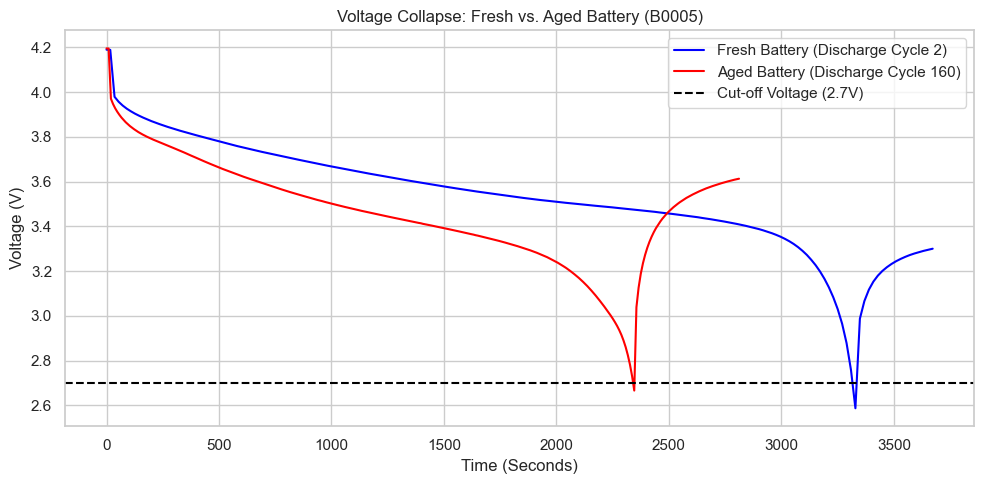

In [17]:
# We will extract the Time vs Voltage series from a FRESH discharge cycle vs an AGED discharge cycle for B0005.

b0005 = scipy.io.loadmat('../Battery_DataSet/B0005.mat')['B0005'][0, 0]['cycle']

fresh_voltage = None
fresh_time = None
aged_voltage = None
aged_time = None

discharge_count = 0
for i in range(b0005.size):
    cycle = b0005[0, i]
    if cycle['type'][0] == 'discharge':
        discharge_count += 1
        
        # Grab the 2nd discharge cycle (Fresh)
        if discharge_count == 2:
            fresh_time = cycle['data']['Time'][0,0][0]
            fresh_voltage = cycle['data']['Voltage_measured'][0,0][0]
        
        # Grab the 160th discharge cycle (Aged - almost dead)
        if discharge_count == 160:
            aged_time = cycle['data']['Time'][0,0][0]
            aged_voltage = cycle['data']['Voltage_measured'][0,0][0]

# --- Let's Plot the Voltage Curves ---
plt.figure(figsize=(10, 5))
plt.plot(fresh_time, fresh_voltage, label='Fresh Battery (Discharge Cycle 2)', color='blue')
plt.plot(aged_time, aged_voltage, label='Aged Battery (Discharge Cycle 160)', color='red')

plt.axhline(y=2.7, color='black', linestyle='--', label='Cut-off Voltage (2.7V)')
plt.title('Voltage Collapse: Fresh vs. Aged Battery (B0005)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.tight_layout()
plt.show()

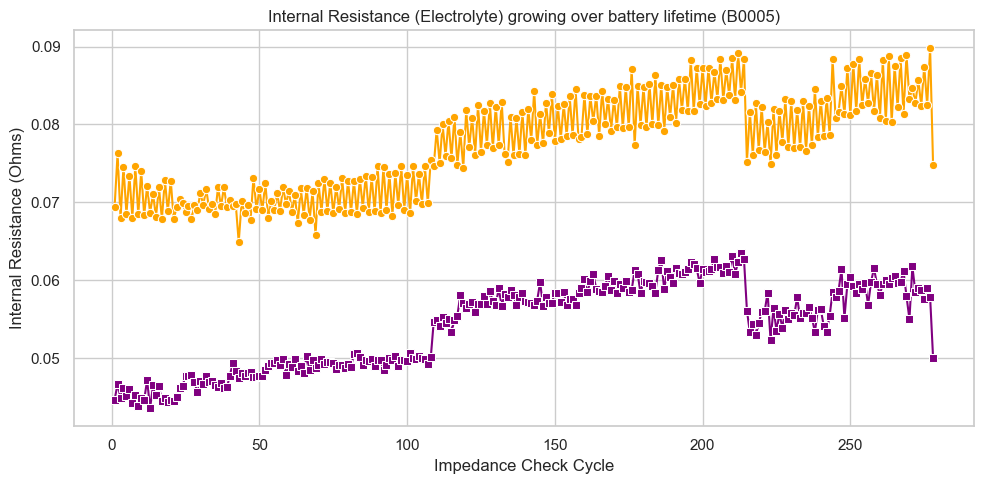

In [ ]:
# Let's extract the Internal Resistance over time from the `impedance` cycles.
# NASA calculated "Re" (electrolyte resistance) from the frequency sweep. 
# As batteries age, Re naturally climbs!

resistance_data = []

# Remember that `b0005` is an array of size 616 containing all operations.
impedance_count = 1
for i in range(b0005.size):
    cycle = b0005[0, i]
    if cycle['type'][0] == 'impedance':
        data = cycle['data']
        # The estimated internal electrolyte resistance
        if 'Re' in data.dtype.names:
            re = data['Re'][0,0][0,0]
            rct = data['Rct'][0,0][0,0]
            
            resistance_data.append({
                'Impedance_Cycle': impedance_count,
                'Re_Ohms': re,
                'Rct_Ohms': rct
            })
            impedance_count += 1
            
# Show the resistance climbing over the battery's lifespan
df_res = pd.DataFrame(resistance_data)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_res, x='Impedance_Cycle', y='Re_Ohms', color='purple', marker='s')
plt.title('Internal Resistance (Electrolyte) growing over battery lifetime (B0005)')
plt.xlabel('Impedance Check Cycle')
plt.ylabel('Internal Resistance (Ohms)')
plt.tight_layout()
plt.show()

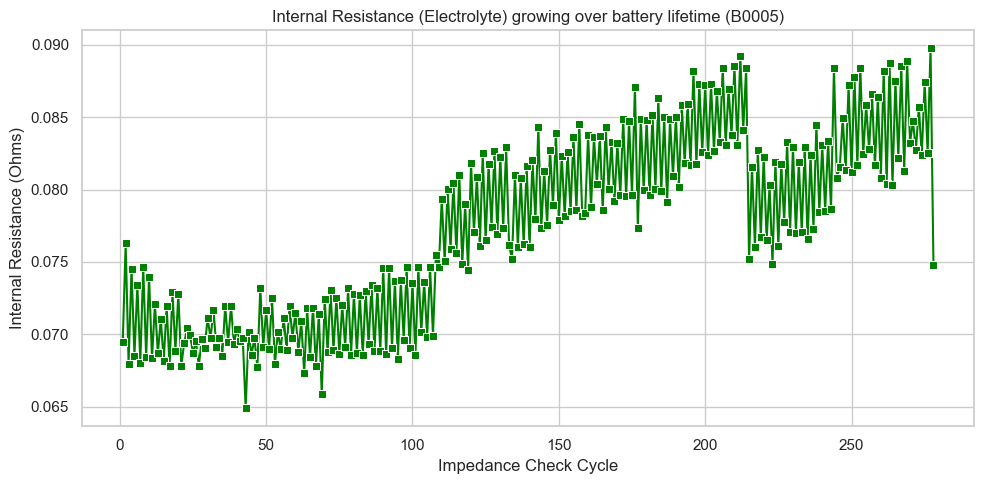

In [21]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_res, x='Impedance_Cycle', y='Rct_Ohms', color='green', marker='s')
plt.title('Internal Resistance (Electrolyte) growing over battery lifetime (B0005)')
plt.xlabel('Impedance Check Cycle')
plt.ylabel('Internal Resistance (Ohms)')
plt.tight_layout()
plt.show()